In [ ]:
#train pipleline\
# sum ampl/ count



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [ ]:
N_BINS = 80

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)


In [ ]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [16]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [17]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [18]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [19]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [20]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D activity maps for ONE neuron.

    Parameters
    ----------
    activity : ndarray
        Shape (T,)

    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    Returns
    -------
    amplitude_activity : (bins, bins)

    real_activity : (bins, bins)
    """

    amplitude = np.abs(activity)

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)

    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        amplitude_activity[yb, xb] += a

        real_activity[yb, xb] += r

    return amplitude_activity

In [21]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [22]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

In [23]:
def spatial_information(rate_map, occupancy_map):
    """
    Spatial Information (bits/spike)

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map

    occupancy_map : ndarray
        Count or probability occupancy
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
        & (rate_map > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    r_bar = np.sum(p * r)

    if r_bar <= EPS:
        return np.nan

    ratio = r / r_bar

    return np.sum(
        p * ratio * np.log2(ratio)
    )

In [24]:
def sparsity(rate_map, occupancy_map):
    """
    Population sparsity
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r**2)

    if mean_r2 <= EPS:
        return np.nan

    return (mean_r**2) / mean_r2

In [25]:
def evaluate_place_cell(rate_map, occupancy_map):
    """
    Compute place-cell metrics from a raw firing-rate map.
    """

    return {
        "Spatial Information": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

#main


In [26]:
import pickle
import numpy as np

layer_name = "d4"

trajectory_results_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    layer_name,
)

In [27]:
print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [28]:
bounds = get_arena_bounds(positions)

print(bounds)

(0.027809273451566696, 0.9689222574234009, 0.0295569971203804, 0.9583374857902527)


In [29]:
trajectory = 0
neuron = 0

trajectory_positions = positions[trajectory]

activity = activations[trajectory, :, neuron]

print("Trajectory positions:", trajectory_positions.shape)
print("Neuron activity:", activity.shape)

Trajectory positions: (450, 2)
Neuron activity: (450,)


In [30]:
x_bin, y_bin, x_edges, y_edges = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

print("x bins:", x_bin.shape)
print("y bins:", y_bin.shape)

print()

print("x range:", x_bin.min(), "to", x_bin.max())
print("y range:", y_bin.min(), "to", y_bin.max())

print()

print("First 10 x bins:", x_bin[:10])
print("First 10 y bins:", y_bin[:10])

x bins: (450,)
y bins: (450,)

x range: 17 to 73
y range: 4 to 72

First 10 x bins: [46 47 47 47 48 48 49 50 51 51]
First 10 y bins: [12 12 12 12 12 12 12 12 12 13]


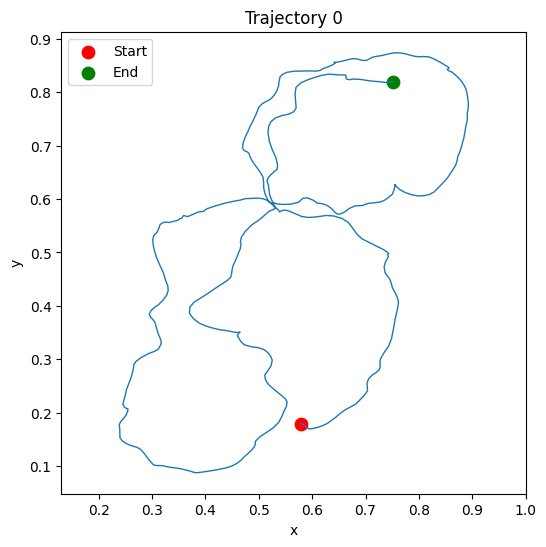

In [31]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_positions[:,0],
    trajectory_positions[:,1],
    lw=1,
)

plt.scatter(
    trajectory_positions[0,0],
    trajectory_positions[0,1],
    c="red",
    s=80,
    label="Start",
)

plt.scatter(
    trajectory_positions[-1,0],
    trajectory_positions[-1,1],
    c="green",
    s=80,
    label="End",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory 0")

plt.legend()
plt.axis("equal")

plt.show()

In [40]:
from itertools import groupby


count_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

print("Count occupancy shape:", len(count_occ))


print()

# Unpack if compute_occupancy_maps returned (count, prob)
if isinstance(count_occ, tuple) and len(count_occ) == 2:
    count_occ, prob_occ = count_occ

print("Count occupancy shape:", count_occ.shape)
print()
print("Total samples:", int(count_occ.sum()))


Count occupancy shape: 2

Count occupancy shape: (80, 80)

Total samples: 450


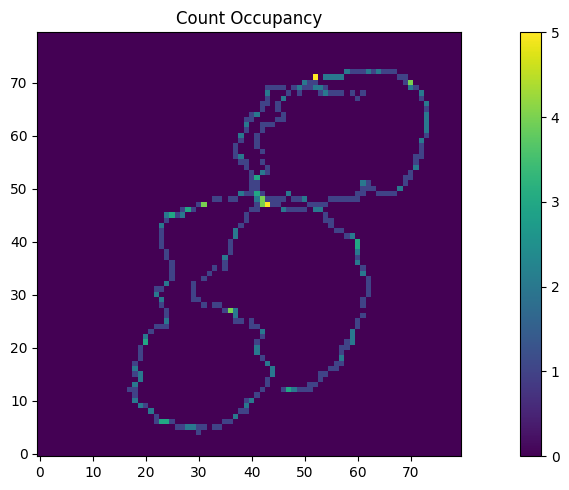

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

im = ax.imshow(
    count_occ,
    origin="lower",
    interpolation="nearest",
)

ax.set_title("Count Occupancy")

plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [45]:
amp_activity = compute_activity_maps(
    activity,
    x_bin,
    y_bin,
)

In [46]:
print("Amplitude Activity Shape:", amp_activity.shape)


print()

print("Total Amplitude:", amp_activity.sum())


Amplitude Activity Shape: (80, 80)

Total Amplitude: 111.7937190250168


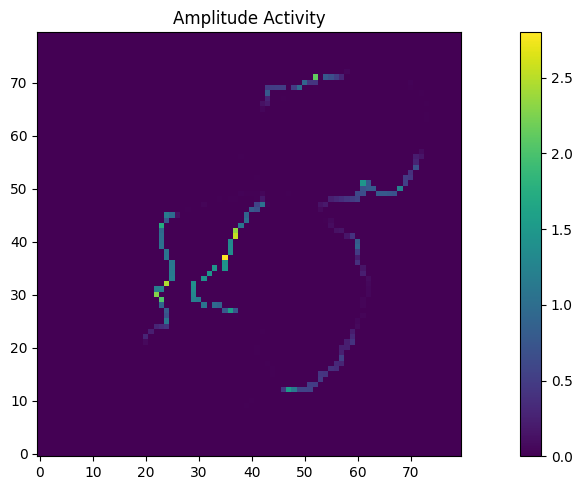

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

im = ax.imshow(
    amp_activity,
    origin="lower",
)

ax.set_title("Amplitude Activity")

plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [50]:
amp_count_rate = compute_firing_rate_map(
    amp_activity,
    count_occ,
)

amp_prob_rate = compute_firing_rate_map(
    amp_activity,
    prob_occ,
)

"""real_count_rate = compute_firing_rate_map(
    real_activity,
    count_occ,
)

real_prob_rate = compute_firing_rate_map(
    real_activity,
    prob_occ,
)"""

'real_count_rate = compute_firing_rate_map(\n    real_activity,\n    count_occ,\n)\n\nreal_prob_rate = compute_firing_rate_map(\n    real_activity,\n    prob_occ,\n)'

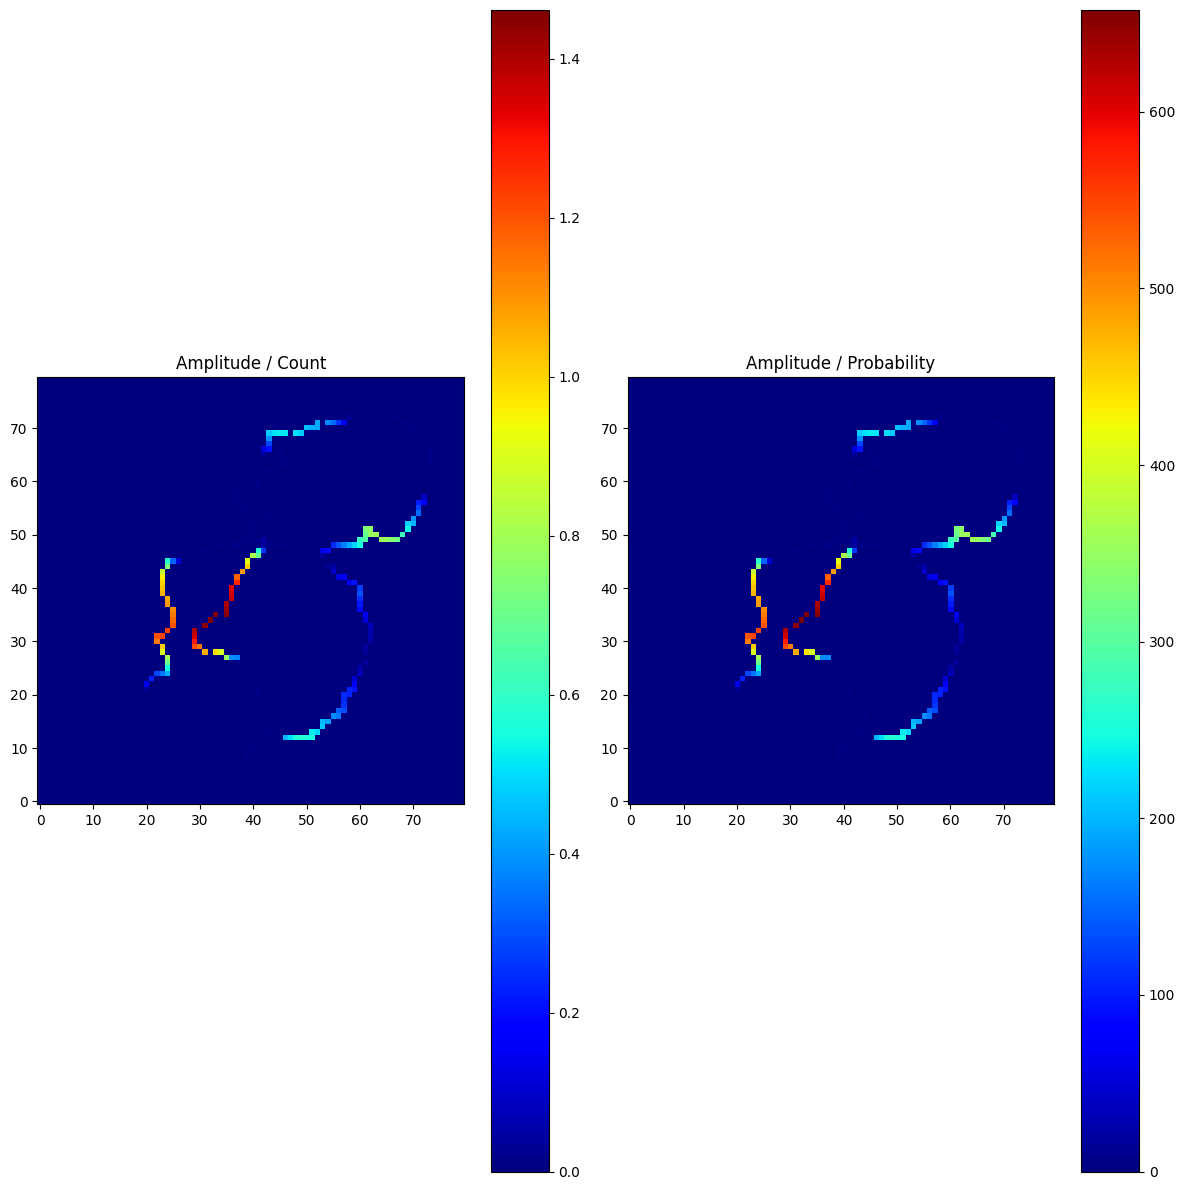

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

maps = [

    ("Amplitude / Count", amp_count_rate),

    ("Amplitude / Probability", amp_prob_rate),

    #("Real / Count", real_count_rate),

    #("Real / Probability", real_prob_rate),

]

for axis, (title, rate_map) in zip(ax.ravel(), maps):

    im = axis.imshow(
        rate_map,
        origin="lower",
        interpolation="nearest",
        cmap="jet",
    )

    axis.set_title(title)

    plt.colorbar(im, ax=axis)

plt.tight_layout()

plt.show()

In [56]:
print("Amplitude / Count:", amp_count_rate.shape)
#print("Amplitude / Probability:", amp_prob_rate.shape)

#print("Real / Probability:", real_prob_rate.shape)

Amplitude / Count: (80, 80)


In [57]:
maps = {
    "Amplitude / Count": (
        amp_count_rate,
        count_occ,
    ),
}

results = {}

for name, (rate_map, occupancy) in maps.items():

    results[name] = evaluate_place_cell(
        rate_map,
        occupancy,
    )

In [58]:
print("\n" + "="*70)
print("PLACE CELL METRICS")
print("="*70)

print(f"{'Method':30s} {'SI':>12s} {'Sparsity':>12s}")

print("-"*70)

for name, metrics in results.items():

    print(
        f"{name:30s}"
        f"{metrics['Spatial Information']:12.5f}"
        f"{metrics['Sparsity']:12.5f}"
    )


PLACE CELL METRICS
Method                                   SI     Sparsity
----------------------------------------------------------------------
Amplitude / Count                  1.41437     0.30359


In [59]:
amp_count_smoothed = smooth_firing_rate_map(amp_count_rate)

amp_prob_smoothed = smooth_firing_rate_map(amp_prob_rate)

#real_count_smoothed = smooth_firing_rate_map(real_count_rate)

#real_prob_smoothed = smooth_firing_rate_map(real_prob_rate)

ValueError: too many values to unpack (expected 3)

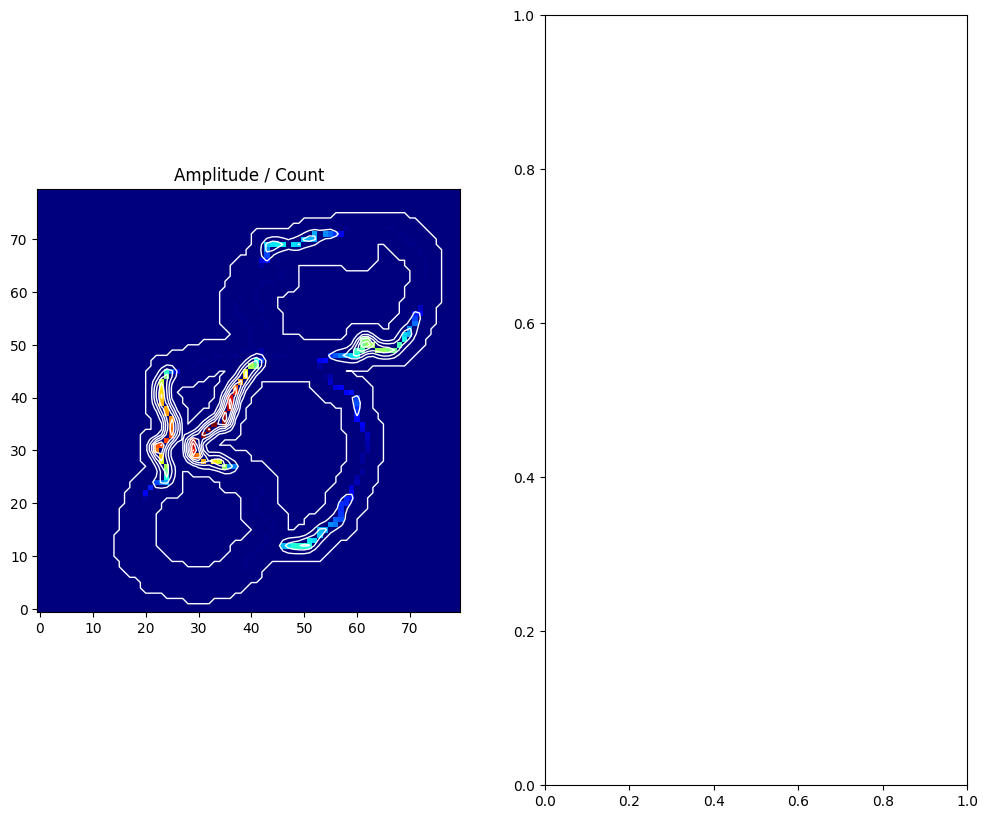

In [64]:
fig, ax = plt.subplots(1,2, figsize=(12,10))

maps = [

    ("Amplitude / Count",
     amp_count_rate,
     amp_count_smoothed),

    """("Amplitude / Probability",
     amp_prob_rate,
     amp_prob_smoothed),

    #("Real / Count",
     #real_count_rate,
     #real_count_smoothed),

    #("Real / Probability",
     #real_prob_rate,
     #real_prob_smoothed),"""
]

for axis, (title, raw, smooth) in zip(ax.ravel(), maps):

    axis.imshow(
        raw,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    axis.contour(
        smooth,
        colors="white",
        linewidths=1,
    )

    axis.set_title(title)

plt.tight_layout()

plt.show()

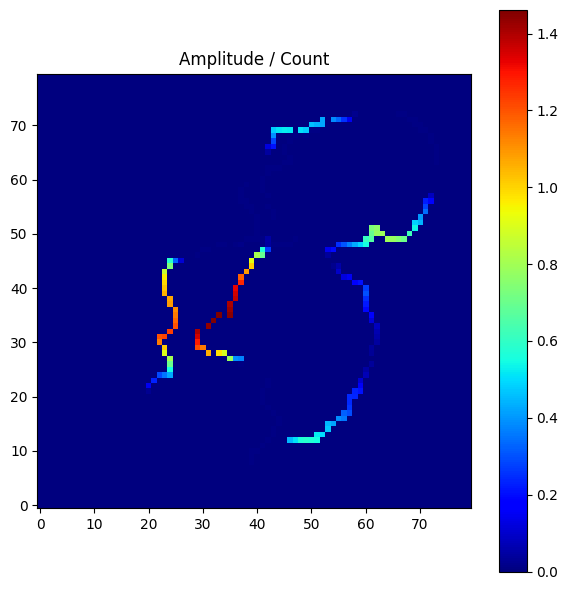

In [65]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    amp_count_rate,
    origin="lower",
    interpolation="nearest",
    cmap="jet",
)

ax.set_title("Amplitude / Count")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [87]:
all_results = []

trajectory = 0

trajectory_positions = positions[trajectory]

x_bin, y_bin, _, _ = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

n_neurons = activations.shape[2]

for neuron in range(n_neurons):

    activity = activations[
        trajectory,
        :,
        neuron,
    ]

    amp_activity, real_activity = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
    )

    amp_count = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    amp_prob = compute_firing_rate_map(
        amp_activity,
        prob_occ,
    )

    real_count = compute_firing_rate_map(
        real_activity,
        count_occ,
    )

    real_prob = compute_firing_rate_map(
        real_activity,
        prob_occ,
    )

    amp_count_s = smooth_firing_rate_map(
        amp_count,
    )

    amp_prob_s = smooth_firing_rate_map(
        amp_prob,
    )

    real_count_s = smooth_firing_rate_map(
        real_count,
    )

    real_prob_s = smooth_firing_rate_map(
        real_prob,
    )

    all_results.append({

        "neuron": neuron,

        "amp_count_smoothed": amp_count_s,
        "amp_prob_smoothed": amp_prob_s,

        "real_count_smoothed": real_count_s,
        "real_prob_smoothed": real_prob_s,

    })

print(f"Processed {len(all_results)} neurons.")

Processed 100 neurons.


In [88]:
def evaluate_place_cell(
    rate_map,
    occupancy_map,
):
    """
    Compute place-cell metrics for one firing-rate map.

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map.

    occupancy_map : ndarray
        Count or probability occupancy map.

    Returns
    -------
    metrics : dict
        Spatial Information and Sparsity.
    """

    return {
        "SI": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

In [89]:
maps = {
    "Amplitude / Count": (
        amp_count_smoothed,
        count_occ,
    ),

    "Amplitude / Probability": (
        amp_prob_smoothed,
        prob_occ,
    ),

    "Real / Count": (
        real_count_smoothed,
        count_occ,
    ),

    "Real / Probability": (
        real_prob_smoothed,
        prob_occ,
    ),
}

results = {}

for name, (rate_map, occ) in maps.items():

    results[name] = evaluate_place_cell(
        rate_map,
        occ,
    )

In [90]:
results = {}

maps = {
    "Amplitude / Count": (amp_count_smoothed, count_occ),
    "Amplitude / Probability": (amp_prob_smoothed, prob_occ),
    "Real / Count": (real_count_smoothed, count_occ),
    "Real / Probability": (real_prob_smoothed, prob_occ),
}

for name, (rate_map, occupancy) in maps.items():

    si = spatial_information(
        rate_map,
        occupancy,
    )

    sp = sparsity(
        rate_map,
        occupancy,
    )

    results[name] = {
        "Spatial Information": si,
        "Sparsity": sp,
    }

In [91]:
print("\n" + "="*70)
print("PLACE CELL METRICS")
print("="*70)

print(f"{'Method':30s} {'SI':>12s} {'Sparsity':>12s}")

print("-"*70)

for name, metrics in results.items():

    print(
        f"{name:30s}"
        f"{metrics['Spatial Information']:12.5f}"
        f"{metrics['Sparsity']:12.5f}"
    )


PLACE CELL METRICS
Method                                   SI     Sparsity
----------------------------------------------------------------------
Amplitude / Count                  1.21969     0.34651
Amplitude / Probability            1.21969     0.34651
Real / Count                       1.31594     0.32990
Real / Probability                 1.31594     0.32990


GRID CELLS


In [223]:
from scipy.ndimage import rotate
from scipy.ndimage import label
from scipy.ndimage import center_of_mass

In [224]:
import numpy as np


def point_correlation(
    rate_map,
    row_shift,
    col_shift,
):
    """
    Fast Pearson correlation between a rate map
    and a shifted copy.
    """

    rows, cols = rate_map.shape

    r1_start = max(0, row_shift)
    r1_end   = min(rows, rows + row_shift)

    r2_start = max(0, -row_shift)
    r2_end   = min(rows, rows - row_shift)

    c1_start = max(0, col_shift)
    c1_end   = min(cols, cols + col_shift)

    c2_start = max(0, -col_shift)
    c2_end   = min(cols, cols - col_shift)

    x = rate_map[
        r1_start:r1_end,
        c1_start:c1_end,
    ]

    y = rate_map[
        r2_start:r2_end,
        c2_start:c2_end,
    ]

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 20:
        return np.nan

    x = x[valid]
    y = y[valid]

    x = x - x.mean()
    y = y - y.mean()

    denom = np.sqrt(
        np.sum(x*x) *
        np.sum(y*y)
    )

    if denom == 0:
        return np.nan

    return np.sum(x*y) / denom


def spatial_autocorrelation(rate_map):

    bins = rate_map.shape[0]

    autocorr = np.empty(
        (2*bins-1,2*bins-1),
        dtype=np.float32,
    )

    shifts = np.arange(
        -(bins-1),
        bins,
        dtype=np.int32,
    )

    for i,row_shift in enumerate(shifts):

        for j,col_shift in enumerate(shifts):

            autocorr[i,j] = point_correlation(
                rate_map,
                row_shift,
                col_shift,
            )

    return autocorr

In [225]:
from scipy.ndimage import maximum_filter

def detect_autocorr_peaks(
    autocorr,
    threshold=0.10,
    neighbourhood=5,
):
    """
    Detect local maxima in the autocorrelogram.
    """

    local_max = (
        autocorr ==
        maximum_filter(
            autocorr,
            size=neighbourhood,
        )
    )

    local_max &= autocorr > threshold

    peaks = np.argwhere(local_max)

    return peaks.astype(float)

In [226]:
def merge_close_peaks(
    peaks,
    min_distance=6,
):
    """
    Merge peaks that are very close together.

    Parameters
    ----------
    peaks : ndarray (N,2)

    min_distance : float
        Peaks closer than this are merged.

    Returns
    -------
    merged_peaks
    """

    if len(peaks) == 0:
        return peaks

    remaining = peaks.tolist()
    merged = []

    while len(remaining):

        current = np.array(remaining.pop(0))

        cluster = [current]

        keep = []

        for p in remaining:

            p = np.array(p)

            if np.linalg.norm(
                current - p
            ) < min_distance:

                cluster.append(p)

            else:

                keep.append(p)

        remaining = keep

        merged.append(
            np.mean(cluster, axis=0)
        )

    return np.array(merged)

In [227]:
def centre_peak(
    peaks,
    shape,
):
    """
    Find centroid closest to image centre.
    """

    centre = np.array(shape) / 2

    distances = np.linalg.norm(
        peaks - centre,
        axis=1,
    )

    return peaks[np.argmin(distances)]


def peak_distances(
    peaks,
    centre,
):
    """
    Euclidean distance from centre to every peak.
    """

    return np.linalg.norm(
        peaks - centre,
        axis=1,
    )


def first_ring_radius(
    peaks,
    centre,
    min_radius=10,
):
    """
    Estimate the radius of the first ring of peaks.
    """

    distances = np.linalg.norm(
        peaks - centre,
        axis=1,
    )

    # Ignore centre peak
    distances = distances[
        distances > min_radius
    ]

    if len(distances) < 6:
        return None

    # Sort by distance
    distances = np.sort(distances)

    # First six surrounding peaks
    first_ring = distances[:6]

    # Remove obvious outliers
    median = np.median(first_ring)

    first_ring = first_ring[
        np.abs(first_ring - median) < 8
    ]

    if len(first_ring) == 0:
        return None

    return np.median(first_ring)

In [228]:
def compute_neuron_grid_score(
    positions,
    activity,
    bounds,
    bins=N_BINS,
    fixed_radius=None,
):
    """
    Compute the complete grid-cell pipeline for one neuron.

    Parameters
    ----------
    fixed_radius : float or None
        If provided, use this radius instead of estimating one.
        Useful for shuffle analysis.
    """

    # --------------------------------------------------
    # Bin positions
    # --------------------------------------------------

    x_bin, y_bin, _, _ = bin_positions(
        positions,
        bins=bins,
        bounds=bounds,
    )

    count_occ, _ = compute_occupancy_maps(
        x_bin,
        y_bin,
        bins=bins,
    )

    # --------------------------------------------------
    # Activity map
    # --------------------------------------------------

    amp_activity, _ = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
        bins=bins,
    )

    # --------------------------------------------------
    # Rate map
    # --------------------------------------------------

    rate_map = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    rate_map = smooth_firing_rate_map(
        rate_map,
    )

    # --------------------------------------------------
    # Spatial autocorrelation
    # --------------------------------------------------

    autocorr = spatial_autocorrelation(
        rate_map,
    )

    # --------------------------------------------------
    # Peak detection
    # --------------------------------------------------

    peaks = detect_autocorr_peaks(
        autocorr,
    )

    peaks = merge_close_peaks(
        peaks,
        min_distance=6,
    )

    if len(peaks) == 0:
        return None

    centre = centre_peak(
        peaks,
        autocorr.shape,
    )

    # --------------------------------------------------
    # Ring radius
    # --------------------------------------------------

    if fixed_radius is None:

        radius = first_ring_radius(
            peaks,
            centre,
        )

    else:

        radius = fixed_radius

    if radius is None:
        return None

    # --------------------------------------------------
    # Grid score
    # --------------------------------------------------

    grid_score, correlations = compute_grid_score(
        autocorr,
        inner_radius=0.5 * radius,
        outer_radius=1.5 * radius,
    )

    return {

        "grid_score": grid_score,

        "correlations": correlations,

        "rate_map": rate_map,

        "autocorr": autocorr,

        "radius": radius,

        "centre": centre,

        "peaks": peaks,

    }

In [229]:
trajectory = 0
neuron = 77

result = compute_neuron_grid_score(
    positions[trajectory],
    activations[trajectory,:,neuron],
    bounds,
)

print("Grid Score:", result["grid_score"])
print("Radius:", result["radius"])

for angle, value in result["correlations"].items():
    print(f"{angle:3d}° : {value:.4f}")

Grid Score: 0.26046732471923617
Radius: 37.48332962798263
 30° : -0.0511
 60° : 0.2122
 90° : -0.0484
120° : 0.2121
150° : -0.0511


Raw peaks: 11
Merged peaks: 11


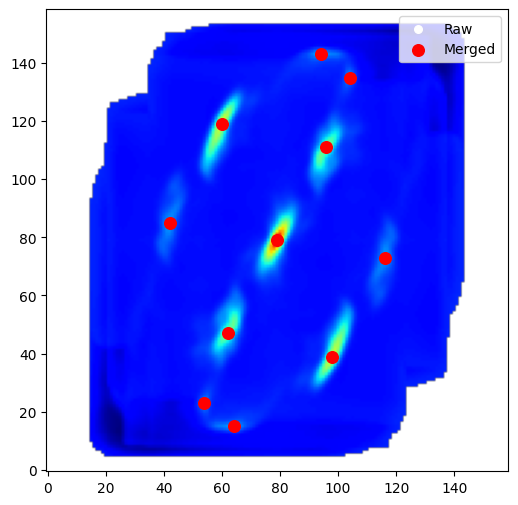

In [230]:
peaks = detect_autocorr_peaks(autocorr)

print("Raw peaks:", len(peaks))

merged = merge_close_peaks(peaks)

print("Merged peaks:", len(merged))

plt.figure(figsize=(6,6))

plt.imshow(
    autocorr,
    origin="lower",
    cmap="jet",
)

plt.scatter(
    peaks[:,1],
    peaks[:,0],
    c="white",
    s=30,
    label="Raw",
)

plt.scatter(
    merged[:,1],
    merged[:,0],
    c="red",
    s=70,
    label="Merged",
)

plt.legend()

plt.show()

In [231]:
def circular_shuffle(
    activity,
    min_shift=20,
):
    """
    Circularly shift a neuron's activity.

    Parameters
    ----------
    activity : (T,)

    min_shift : int
        Minimum shift to avoid trivial shuffles.

    Returns
    -------
    shuffled_activity
    """

    T = len(activity)

    shift = np.random.randint(
        min_shift,
        T - min_shift,
    )

    shuffled = np.roll(
        activity,
        shift,
    )

    return shuffled

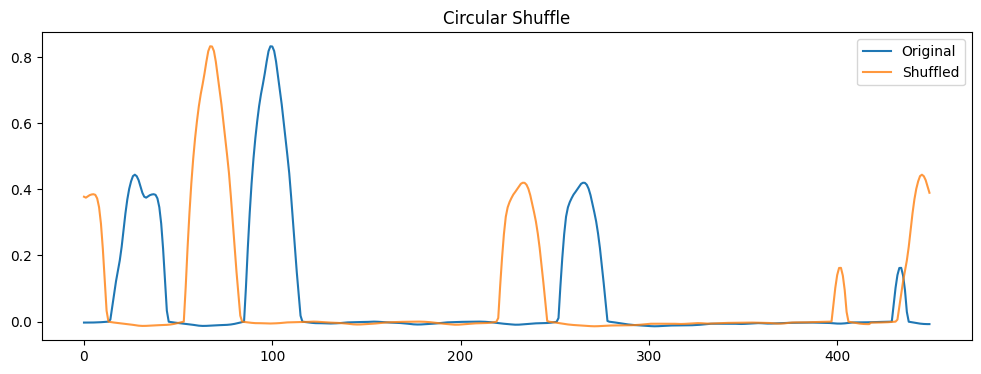

In [232]:
activity = activations[0,:,77]

shuffle = circular_shuffle(activity)

plt.figure(figsize=(12,4))

plt.plot(activity,label="Original")

plt.plot(
    shuffle,
    label="Shuffled",
    alpha=0.8,
)

plt.legend()

plt.title("Circular Shuffle")

plt.show()

In [233]:
activity = activations[0,:,77]

shuffle = circular_shuffle(activity)

shuffle_result = compute_neuron_grid_score(
    positions[0],
    shuffle,
    bounds,
)

print("Original :", result["grid_score"])

print("Shuffle  :", shuffle_result["grid_score"])

Original : 0.26046732471923617
Shuffle  : -0.09077992604954185


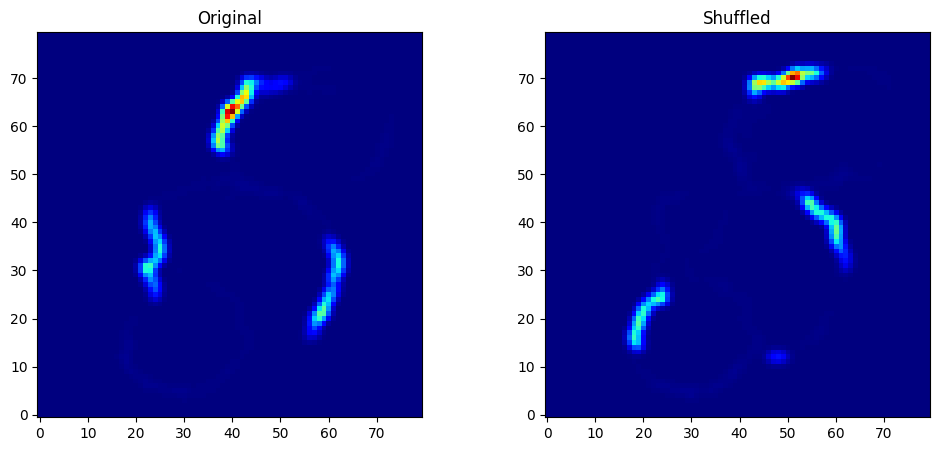

In [234]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

ax[0].imshow(
    result["rate_map"],
    origin="lower",
    cmap="jet",
)

ax[0].set_title("Original")

ax[1].imshow(
    shuffle_result["rate_map"],
    origin="lower",
    cmap="jet",
)

ax[1].set_title("Shuffled")

plt.show()

In [235]:
shuffle_scores = []

for i in range(10):

    shuffled = circular_shuffle(
        activations[0,:,77]
    )

    shuffle_result = compute_neuron_grid_score(
        positions[0],
        shuffled,
        bounds,
    )

    if shuffle_result is not None:

        shuffle_scores.append(
            shuffle_result["grid_score"]
        )

print(shuffle_scores)

[-0.1066085733849612, -0.08761727552386504, 0.02612989712980529, 0.5601001064125668, -0.02813581416330499, -0.18786392050429845, -0.09282999751492875, -0.22362182529958158, -0.24166505985348727, -0.00970069849947787]


In [ ]:
"""import time

trajectory = 0
neuron = 77

original = compute_neuron_grid_score(
    positions[trajectory],
    activations[trajectory,:,neuron],
    bounds,
)

radius = original["radius"]

start = time.time()

for i in range(10):

    shuffled = circular_shuffle(
        activations[trajectory,:,neuron]
    )

    _ = compute_neuron_grid_score(
        positions[trajectory],
        shuffled,
        bounds,
        fixed_radius=radius,
    )
    x_bin
    y_bin
    count_occ

end = time.time()

elapsed = end - start

print(f"10 shuffles took {elapsed:.2f} seconds")
print(f"Estimated 250 shuffles: {elapsed*25:.1f} seconds")"""

10 shuffles took 57.67 seconds
Estimated 250 shuffles: 1441.7 seconds


In [236]:
trajectory = 0
neuron = 77

# =====================================================
# Original neuron
# =====================================================

original = compute_neuron_grid_score(
    positions[trajectory],
    activations[trajectory,:,neuron],
    bounds,
)

original_score = original["grid_score"]
radius = original["radius"]

print(f"Original Score : {original_score:.3f}")
print(f"Fixed Radius   : {radius:.2f}")

# =====================================================
# Shuffle distribution
# =====================================================

shuffle_scores = []

N_SHUFFLES = 250

for i in range(N_SHUFFLES):

    shuffled = circular_shuffle(
        activations[trajectory,:,neuron]
    )

    shuffle_result = compute_neuron_grid_score(
        positions[trajectory],
        shuffled,
        bounds,
        fixed_radius=radius,
    )

    if shuffle_result is not None:
        shuffle_scores.append(
            shuffle_result["grid_score"]
        )

shuffle_scores = np.array(shuffle_scores)

threshold = np.percentile(
    shuffle_scores,
    95,
)

print()
print(f"Number of shuffles : {len(shuffle_scores)}")
print(f"Mean               : {shuffle_scores.mean():.3f}")
print(f"Std                : {shuffle_scores.std():.3f}")
print(f"Min                : {shuffle_scores.min():.3f}")
print(f"Max                : {shuffle_scores.max():.3f}")
print(f"95% Threshold      : {threshold:.3f}")
print()
print("Grid Cell:", original_score > threshold)

Original Score : 0.260
Fixed Radius   : 37.48

Number of shuffles : 250
Mean               : -0.008
Std                : 0.245
Min                : -0.489
Max                : 0.968
95% Threshold      : 0.541

Grid Cell: False


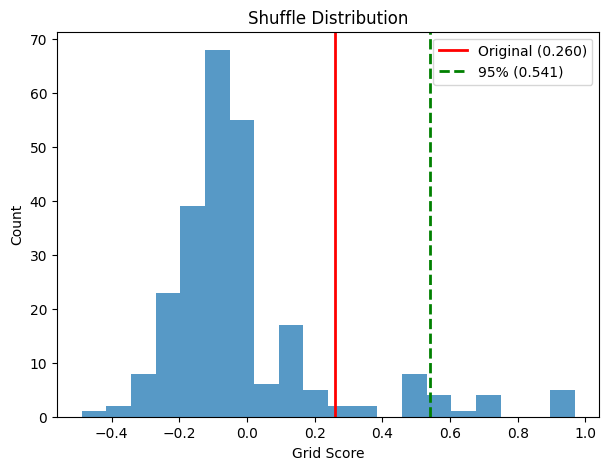

In [237]:
plt.figure(figsize=(7,5))

plt.hist(
    shuffle_scores,
    bins=20,
    alpha=0.75,
)

plt.axvline(
    original_score,
    color="red",
    linewidth=2,
    label=f"Original ({original_score:.3f})",
)

plt.axvline(
    threshold,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"95% ({threshold:.3f})",
)

plt.xlabel("Grid Score")
plt.ylabel("Count")
plt.title("Shuffle Distribution")

plt.legend()

plt.show()

In [238]:
results = []

trajectory = 0

for neuron in range(activations.shape[2]):

    result = compute_neuron_grid_score(
        positions[trajectory],
        activations[trajectory, :, neuron],
        bounds,
    )

    if result is None:
        continue

    results.append({
        "neuron": neuron,
        "score": result["grid_score"],
        "radius": result["radius"],
        "rate_map": result["rate_map"],
        "autocorr": result["autocorr"],
        "peaks": result["peaks"],
    })

In [239]:
results = sorted(
    results,
    key=lambda x: x["score"],
    reverse=True,
)

print("Top 20 Grid Scores\n")

for r in results[:20]:
    print(
        f"Neuron {r['neuron']:3d} : {r['score']:.3f}"
    )

Top 20 Grid Scores

Neuron  22 : 0.267
Neuron  77 : 0.260
Neuron  49 : 0.257
Neuron  82 : 0.211
Neuron  78 : 0.200
Neuron  73 : 0.187
Neuron  59 : 0.113
Neuron  76 : 0.081
Neuron   0 : 0.046
Neuron  21 : 0.042
Neuron  94 : 0.024
Neuron  13 : -0.000
Neuron  54 : -0.004
Neuron  93 : -0.012
Neuron   9 : -0.018
Neuron  31 : -0.019
Neuron  37 : -0.040
Neuron  23 : -0.054
Neuron  86 : -0.058
Neuron  27 : -0.070


5 candidate neurons
[22, 77, 49, 82, 78]


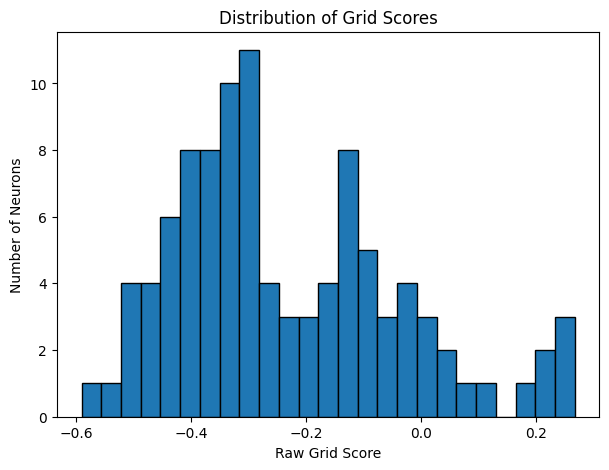

Mean : -0.234
Std  : 0.195
Max  : 0.267


In [240]:
scores = [r["score"] for r in results]
candidate_threshold = 0.20

candidates = [
    r for r in results
    if r["score"] >= candidate_threshold
]

print(f"{len(candidates)} candidate neurons")

print(
    [r["neuron"] for r in candidates]
)
plt.figure(figsize=(7,5))

plt.hist(
    scores,
    bins=25,
    edgecolor="black",
)

plt.xlabel("Raw Grid Score")
plt.ylabel("Number of Neurons")
plt.title("Distribution of Grid Scores")

plt.show()

print(f"Mean : {np.mean(scores):.3f}")
print(f"Std  : {np.std(scores):.3f}")
print(f"Max  : {np.max(scores):.3f}")

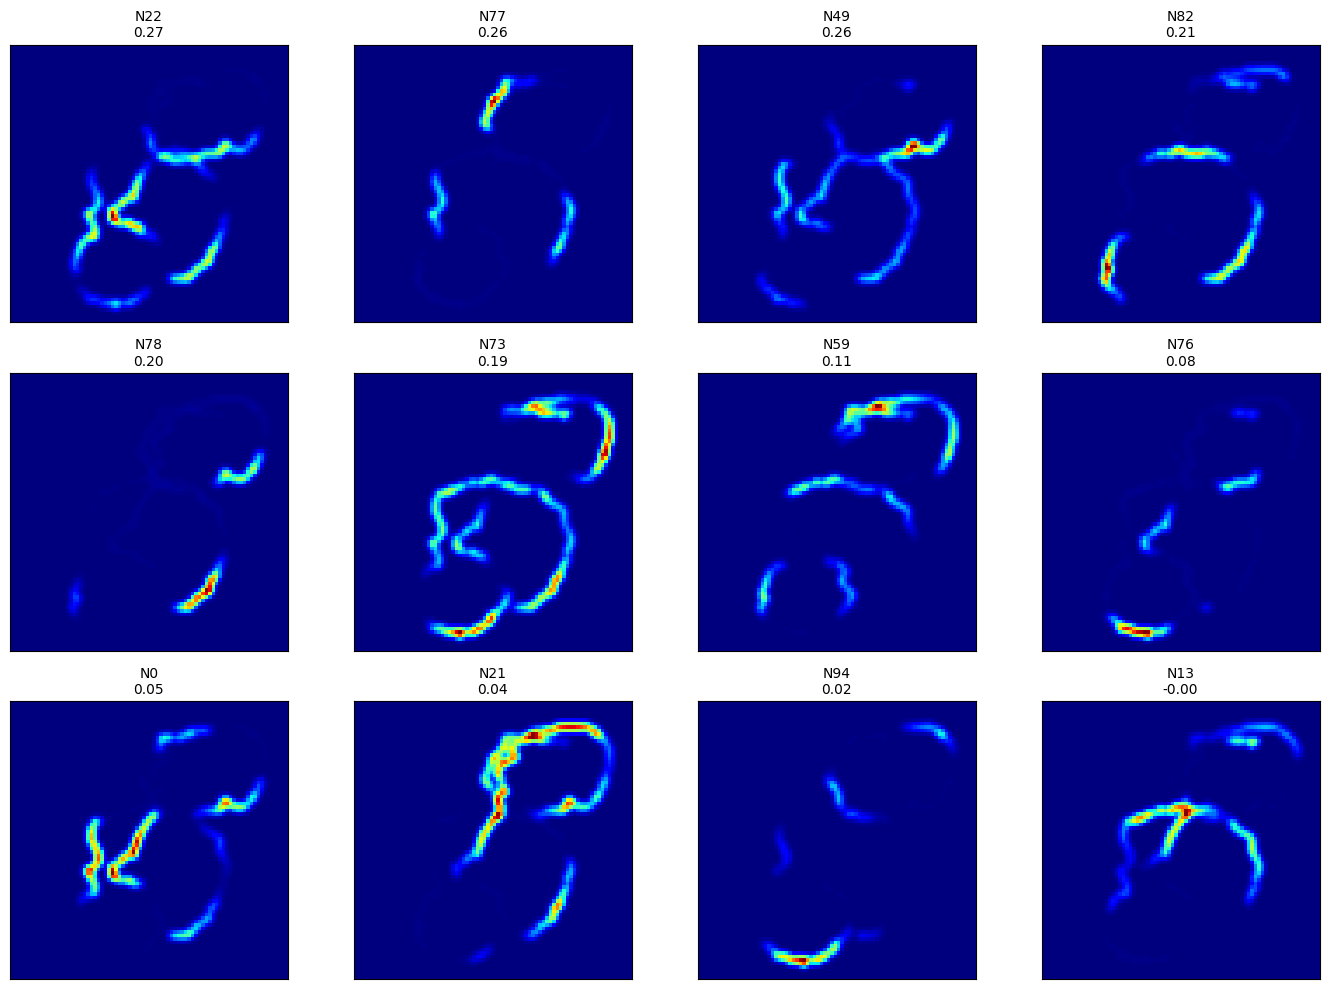

In [241]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(14,10),
)

axes = axes.ravel()

for ax, r in zip(axes, results[:20]):

    ax.imshow(
        r["rate_map"],
        origin="lower",
        cmap="jet",
    )

    ax.set_title(
        f"N{r['neuron']}\n{r['score']:.2f}",
        fontsize=10,
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

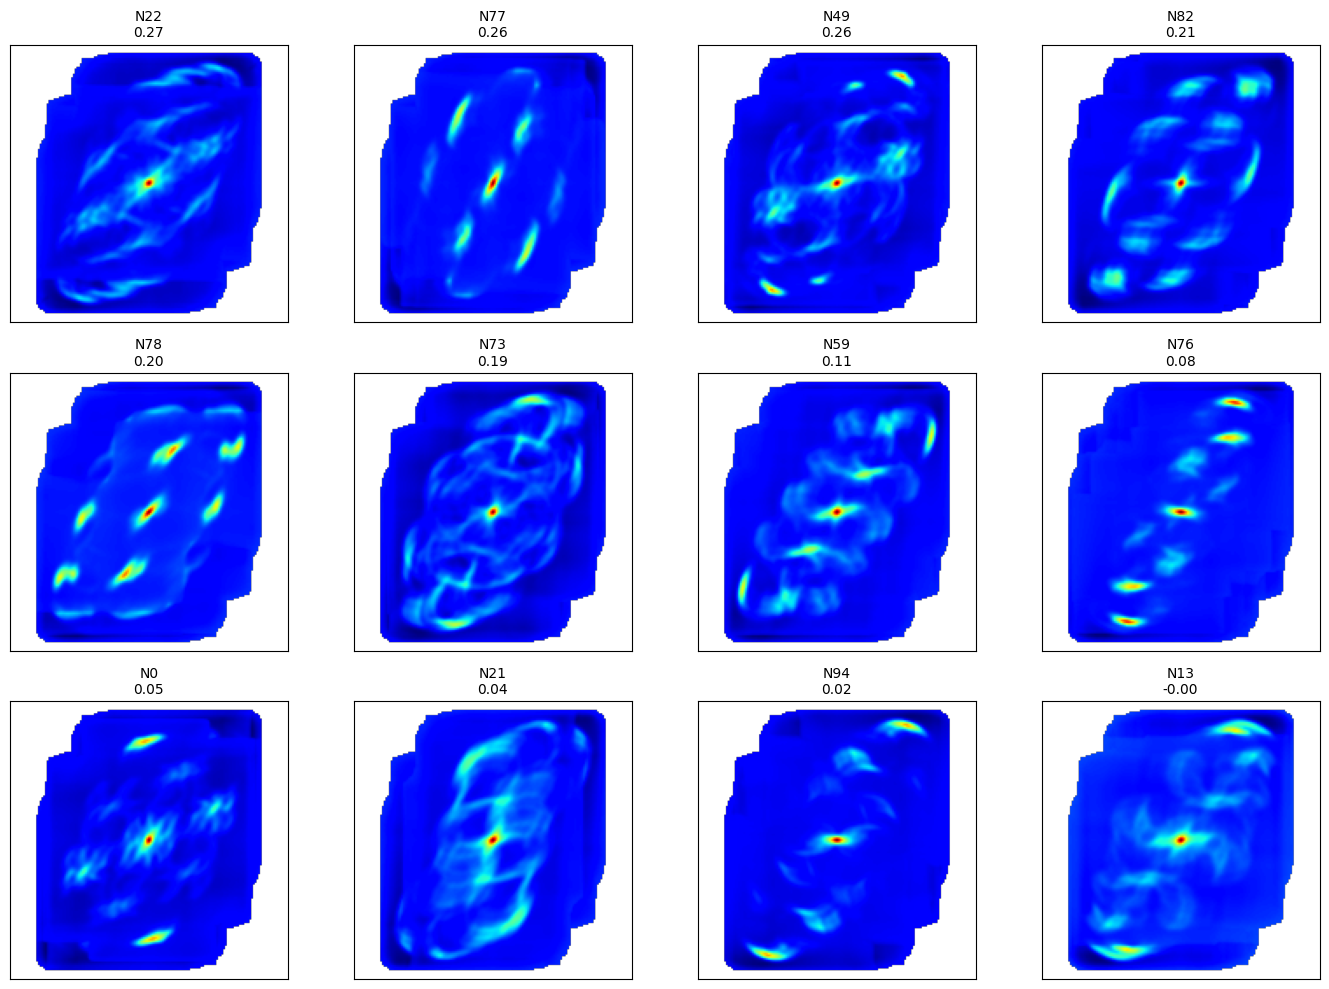

In [242]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(14,10),
)

axes = axes.ravel()

for ax, r in zip(axes, results[:12]):

    ax.imshow(
        r["autocorr"],
        origin="lower",
        cmap="jet",
    )

    ax.set_title(
        f"N{r['neuron']}\n{r['score']:.2f}",
        fontsize=10,
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

In [243]:
candidate_threshold = 0.20

candidates = [
    r for r in results
    if r["score"] >= candidate_threshold
]

print(f"{len(candidates)} candidate neurons")

print(
    [r["neuron"] for r in candidates]
)

5 candidate neurons
[22, 77, 49, 82, 78]


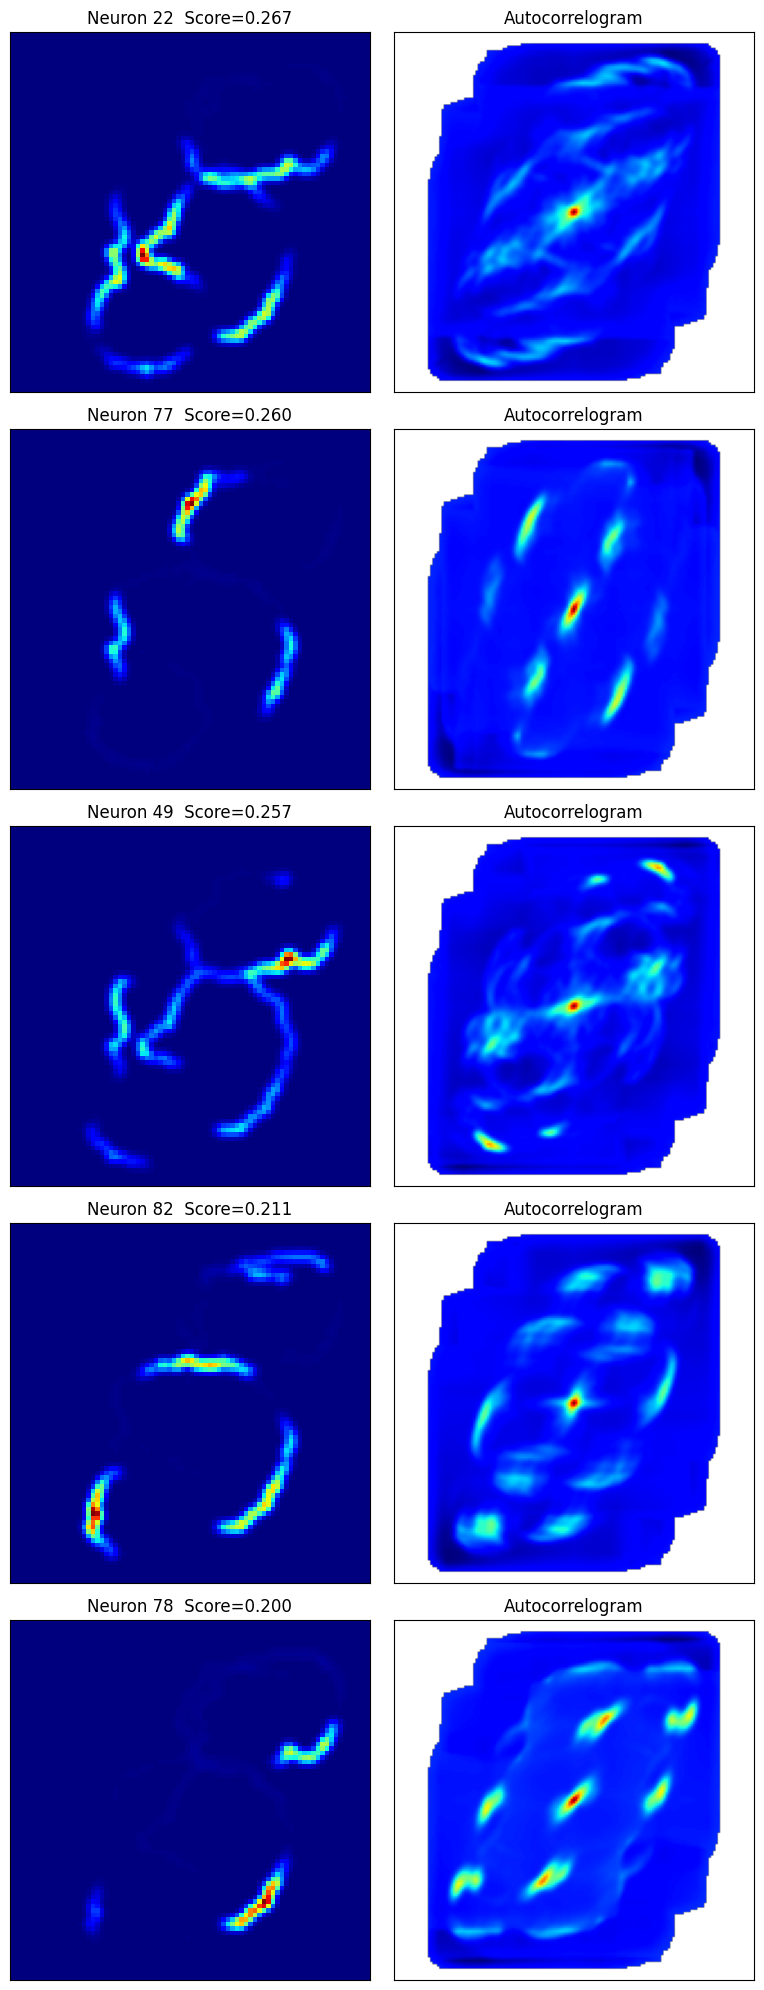

In [244]:
fig, axes = plt.subplots(
    len(candidates),
    2,
    figsize=(8, 4*len(candidates))
)

for ax_row, r in zip(axes, candidates):

    # Rate map
    ax_row[0].imshow(
        r["rate_map"],
        origin="lower",
        cmap="jet",
    )
    ax_row[0].set_title(
        f"Neuron {r['neuron']}  Score={r['score']:.3f}"
    )
    ax_row[0].set_xticks([])
    ax_row[0].set_yticks([])

    # Autocorrelogram
    ax_row[1].imshow(
        r["autocorr"],
        origin="lower",
        cmap="jet",
    )
    ax_row[1].set_title("Autocorrelogram")
    ax_row[1].set_xticks([])
    ax_row[1].set_yticks([])

plt.tight_layout()
plt.show()